<a href="https://colab.research.google.com/github/slavadelik/GO2025/blob/main/%D0%A1%D0%BE%D1%80%D0%B5%D0%B2%D0%BD%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch import nn, optim
import zipfile
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torch.optim.swa_utils import AveragedModel, SWALR
from torchvision import datasets, transforms, models
import warnings
from google.colab import files
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")


Используется устройство: cpu


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dl-2025-competition-1
with zipfile.ZipFile("dl-2025-competition-1.zip", "r") as zip_ref:
    zip_ref.extractall("dl-2025-competition-1")
data_dir = 'dl-2025-competition-1/data'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

Saving kaggle.json to kaggle (4).json
dl-2025-competition-1.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# 1. Настройка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


Используемое устройство: cpu


In [ ]:
# Считаем количество изображений в каждом классе
class_counts = {}
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))

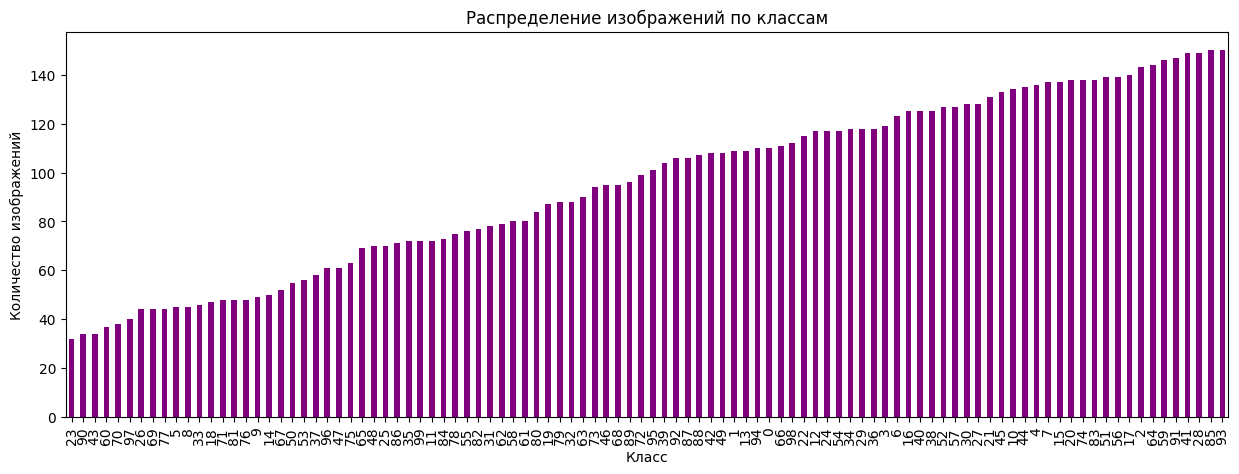

In [ ]:
# Визуализация
plt.figure(figsize=(15, 5))
pd.Series(class_counts).sort_values().plot(kind='bar', color='purple')
plt.title('Распределение изображений по классам')
plt.xlabel('Класс')
plt.ylabel('Количество изображений')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Статистика
print(f"Всего классов: {len(class_counts)}")
print(f"Медианное количество на класс: {pd.Series(class_counts).median()}")
print(f"Максимальное: {pd.Series(class_counts).max()}")
print(f"Минимальное: {pd.Series(class_counts).min()}")

Всего классов: 100
Медианное количество на класс: 100.0
Максимальное: 150
Минимальное: 32


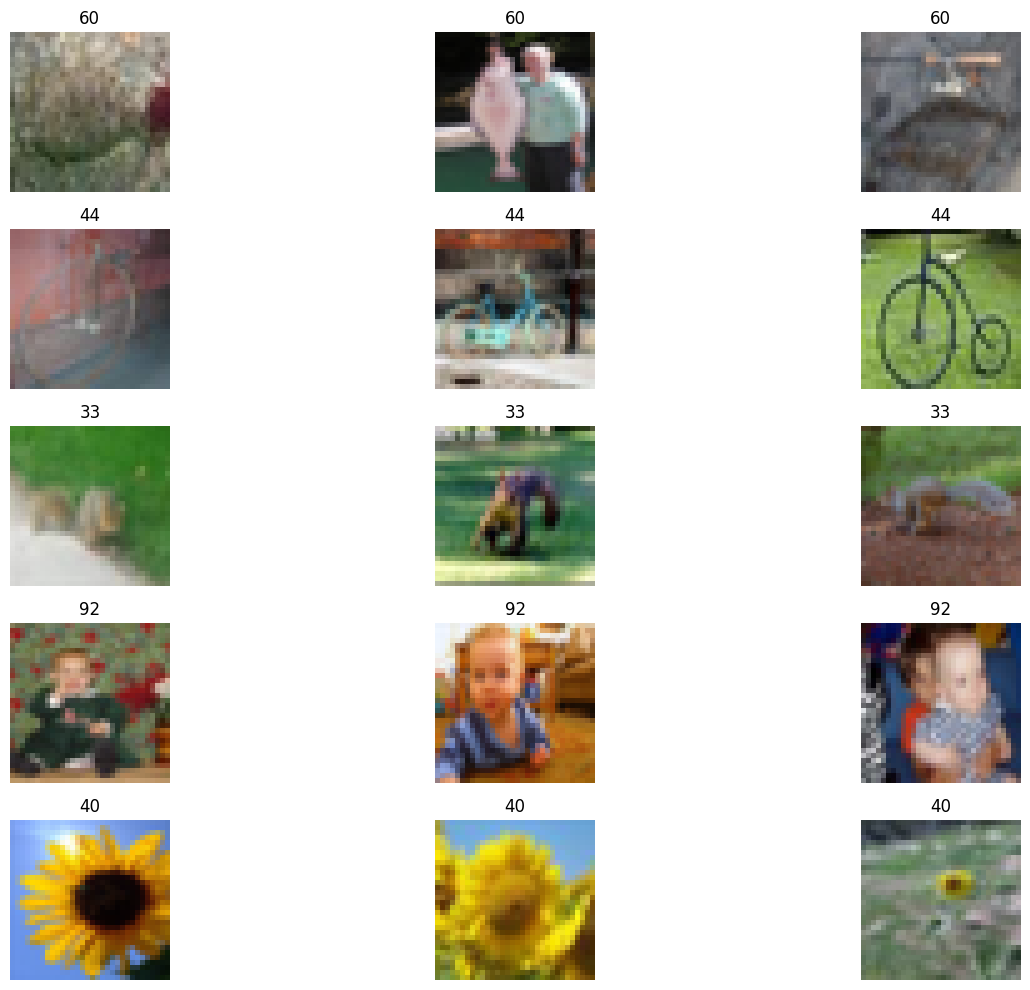

In [ ]:
# Выбираем случайные классы
sample_classes = list(class_counts.keys())[:5]  # Первые 5 классов
# Отображаем по 3 примера из каждого
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(sample_classes):
    class_dir = os.path.join(train_dir, class_name)
    images = os.listdir(class_dir)[:3]  # Берем 3 первых изображения

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(5, 3, i*3 + j + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
basic_transform = A.Compose([
    A.Resize(256, 256),
    A.CenterCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],  # значения для ImageNet
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train

        if is_train:
            # Для тренировочных данных (с классами)
            self.classes = sorted(os.listdir(root_dir))
            self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
            self.samples = []

            for class_name in self.classes:
                class_dir = os.path.join(root_dir, class_name)
                for img_name in os.listdir(class_dir):
                    self.samples.append((
                        os.path.join(class_dir, img_name),
                        self.class_to_idx[class_name]
                    ))
        else:
            # Для тестовых данных (без классов)
            self.samples = [
                os.path.join(root_dir, f)
                for f in os.listdir(root_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.is_train:
            img_path, label = self.samples[idx]
        else:
            img_path = self.samples[idx]
            label = -1  # Фиктивная метка для теста

        img = Image.open(img_path).convert('RGB')
        img = np.array(img)

        if self.transform:
            transformed = self.transform(image=img)
            img = transformed['image']

        return img, label

In [ ]:
# Создание датасетов
train_dataset = CustomDataset(
    train_dir,
    transform=basic_transform,
    is_train=True
)

test_dataset = CustomDataset(
    test_dir,
    transform=basic_transform,  # Для теста используем базовые преобразования
    is_train=False
)

# Создание DataLoader'ов
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


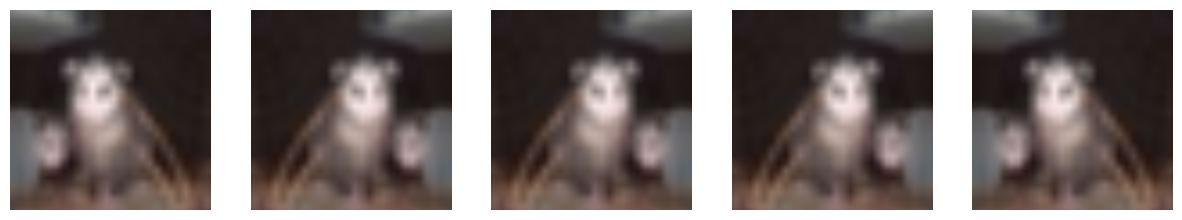

In [ ]:
def visualize_augmentations(dataset, idx=0, samples=5):
    dataset.transform = A.Compose([
        t for t in dataset.transform
        if not isinstance(t, (A.Normalize, ToTensorV2))
    ])

    fig, axes = plt.subplots(1, samples, figsize=(15, 5))
    for i in range(samples):
        img, _ = dataset[idx]
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

# Визуализируем аугментации для первого изображения
visualize_augmentations(train_dataset, idx=0)

In [ ]:
# задание 3

In [ ]:
# Подготовка данных
class SimpleDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        self.transform = transform
        self.images = []
        self.labels = []

        if is_train:
            # Для тренировочных данных (с классами в подпапках)
            for class_idx, class_name in enumerate(sorted(os.listdir(root_dir))):
                class_dir = os.path.join(root_dir, class_name)
                for img_name in os.listdir(class_dir):
                    self.images.append(os.path.join(class_dir, img_name))
                    self.labels.append(class_idx)
        else:
            # Для тестовых данных (все файлы в одной папке)
            for img_name in sorted(os.listdir(root_dir)):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(root_dir, img_name))
                    self.labels.append(-1)  # Фиктивная метка для теста

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = np.array(img)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, self.labels[idx]

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class SimpleUpscaleModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.upscale = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU()
        )
        self.model = base_model

    def forward(self, x):
        x = self.upscale(x)
        return self.model(x)


In [ ]:
# Функции обучения
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, scheduler=None):
    """
    Исправленная функция обучения:
    - Изменил параметр `epochs` на `num_epochs` чтобы избежать конфликта
    - Добавил scheduler как опциональный параметр
    """
    train_losses = []
    val_losses = []
    accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        if scheduler:
            scheduler.step()

    return train_losses, val_losses, accuracies

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total


In [ ]:
train_dataset = SimpleDataset(train_dir, transform=basic_transform)
test_dataset = SimpleDataset(test_dir, transform=basic_transform, is_train=False)

# Разделение на train/val
train_idx, val_idx = train_test_split(range(len(train_dataset)), test_size=0.2, stratify=train_dataset.labels)
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Инициализация моделей
num_classes = len(set(train_dataset.labels))
model_basic = SimpleCNN(num_classes).to(device)
model_advanced = SimpleCNN(num_classes).to(device)
model_upscale = SimpleUpscaleModel(SimpleCNN(num_classes)).to(device)

# Обучение моделей
criterion = nn.CrossEntropyLoss()

In [ ]:
print("Training with basic augmentations...")
optimizer = optim.Adam(model_basic.parameters(), lr=0.001)
train_losses_basic, val_losses_basic, acc_basic = train_model(
    model=model_basic,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=3  # Используем именованный параметр
)

Training with basic augmentations...


Epoch 1/3:   0%|          | 0/238 [00:01<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x50176 and 16384x128)

In [ ]:
# 3. Трансформации данных
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# 4. Создание датасетов
class TestDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.image_files = [f for f in os.listdir(folder)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data = TestDataset(test_dir, transform=test_transform)

In [ ]:
# 5. Создание DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# 6. Создание модели
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(train_data.classes))
model = model.to(device)

In [ ]:
# 7. Функции для обучения
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def train_model(epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        scheduler.step()
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

In [ ]:
# 8. Обучение модели
print("Начинаем обучение...")
train_model(epochs=5)

Начинаем обучение...


KeyboardInterrupt: 

In [ ]:
# 9. Предсказание на тестовых данных
def predict_test_data():
    model.eval()
    all_preds = []
    all_files = []

    with torch.no_grad():
        for images, filenames in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_files.extend(filenames)

    return all_files, all_preds

print("Делаем предсказания...")
test_files, test_preds = predict_test_data()

Делаем предсказания...


KeyboardInterrupt: 

In [ ]:
# 10. Сохранение результатов
results = pd.DataFrame({
    'filename': test_files,
    'class': [train_data.classes[p] for p in test_preds],
    'class_id': test_preds
})

results.to_csv('test_predictions.csv', index=False)
print("Результаты сохранены в test_predictions.csv")

In [ ]:
# Сохранение в правильном формате
submission = pd.DataFrame({
    'filename': test_files,
    'class': [train_data.classes[p] for p in test_preds]  # Или просто test_preds
})
submission.to_csv('submission.csv', index=False)

# Проверка первых строк
print(submission.head())

In [ ]:
submission = pd.DataFrame({
    'id': [f.split('.')[0] for f in test_files],  # Без расширения .png
    'label': [train_data.classes[p] for p in test_preds]  # Или другой требуемый столбец
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

In [ ]:
!kaggle competitions submit -c dl-2025-competition-1 -f submission.csv

usage: kaggle competitions submit [-h] [-f FILE_NAME] [-k KERNEL] -m MESSAGE
                                  [-v VERSION] [-q]
                                  [competition]
kaggle competitions submit: error: the following arguments are required: -m/--message


In [ ]:
# 1. Простой генератор данных (GAN-based)
class SimpleGenerator(nn.Module):
    def __init__(self, num_classes, latent_dim=100):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, latent_dim)

        self.model = nn.Sequential(
            nn.Linear(latent_dim*2, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 3*128*128),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        img = self.model(gen_input)
        return img.view(img.size(0), 3, 128, 128)

In [ ]:
 #2. Функция для генерации данных
def generate_images(generator, num_images_per_class, class_labels, device):
    generator.eval()
    images = []
    labels = []

    with torch.no_grad():
        for class_idx in class_labels:
            # Генерируем для каждого класса
            noise = torch.randn(num_images_per_class, 100).to(device)
            labels_tensor = torch.full((num_images_per_class,), class_idx).to(device)

            generated = generator(noise, labels_tensor)
            generated = (generated * 0.5 + 0.5).clamp(0, 1)  # Нормализация [0, 1]

            images.extend(generated.cpu().numpy())
            labels.extend([class_idx]*num_images_per_class)

    return np.array(images), np.array(labels)


In [ ]:
# 3. Датасет для сгенерированных данных
class GeneratedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].transpose(1, 2, 0)  # CHW -> HWC
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        return img, label

In [ ]:
class SimpleDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Основная сеть для обработки изображения
        self.image_network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1)
        )

        # Сеть для обработки меток классов
        self.label_embedding = nn.Embedding(num_classes, 512)

        # Финальный классификатор
        self.final = nn.Sequential(
            nn.Linear(1024, 1),  # Объединяем features изображения и метки
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Обработка изображения
        img_features = self.image_network(img)
        img_features = img_features.view(img_features.size(0), -1)

        # Обработка метки
        label_features = self.label_embedding(labels)

        # Объединение features
        combined = torch.cat([img_features, label_features], dim=1)

        # Финальная классификация
        validity = self.final(combined)
        return validity

In [ ]:
# 4. Аугментации для сгенерированных данных
gen_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2()
])

In [ ]:
# 5. Обучение генератора
def train_generator(generator, discriminator, dataloader, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator.to(device)
    discriminator.to(device)

    criterion = nn.BCELoss()
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

    for epoch in range(num_epochs):
        for real_imgs, real_labels in tqdm(dataloader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            real_labels = real_labels.to(device)

            # Обучаем дискриминатор
            d_optimizer.zero_grad()

            # Реальные изображения
            real_validity = discriminator(real_imgs, real_labels)
            real_loss = criterion(real_validity, torch.ones(batch_size, 1).to(device))

            # Сгенерированные изображения
            noise = torch.randn(batch_size, 100).to(device)
            gen_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
            gen_imgs = generator(noise, gen_labels)
            fake_validity = discriminator(gen_imgs.detach(), gen_labels)
            fake_loss = criterion(fake_validity, torch.zeros(batch_size, 1).to(device))

            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()

            # Обучаем генератор
            g_optimizer.zero_grad()
            validity = discriminator(gen_imgs, gen_labels)
            g_loss = criterion(validity, torch.ones(batch_size, 1).to(device))
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch {epoch+1}/{num_epochs} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    return generator


In [ ]:
# 6. Оценка влияния на модель
def evaluate_impact(base_model, train_loader, val_loader, generator, num_classes):
    # Генерируем дополнительные данные
    gen_images, gen_labels = generate_images(generator, 50, range(num_classes), device)
    gen_dataset = GeneratedDataset(gen_images, gen_labels, gen_transform)

    # Объединяем с оригинальными данными
    combined_dataset = ConcatDataset([train_loader.dataset, gen_dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=32, shuffle=True)

    # Обучаем модель на комбинированных данных
    optimizer = optim.Adam(base_model.parameters(), lr=0.001)
    train_losses, val_losses, accuracies = train_model(
        base_model, combined_loader, val_loader, criterion, optimizer, num_epochs=5
    )

    return train_losses, val_losses, accuracies

In [ ]:
# Пример использования:
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Функция потерь
criterion = nn.BCELoss()
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Инициализация моделей
    num_classes = 10
    generator = SimpleGenerator(num_classes).to(device)
    discriminator = SimpleDiscriminator(num_classes).to(device)

    # 1. Обучаем генератор
    print("Training generator...")
    trained_generator = train_generator(generator, discriminator, train_loader, num_epochs=5)

    # 2. Оцениваем влияние
    print("Evaluating impact...")
    train_losses, val_losses, accuracies = evaluate_impact(
        model_basic, train_loader, val_loader, trained_generator, num_classes
    )
    # 3. Визуализация результатов
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.plot(accuracies, label='Accuracy')
    plt.legend()
    plt.show()

Training generator...


  0%|          | 0/238 [00:01<?, ?it/s]


IndexError: index out of range in self